In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle

In [2]:
def ODE_system_solver(f, y0, t0, final_t, step = 1e-4):

    ts = np.arange(t0, final_t, step)
    ys = np.empty((len(ts), len(y0)), dtype=np.float32)
    ys[0] = y0

    for i, t in enumerate(ts[:-1]):
        ys[i + 1] = ys[i] + f(t, ys[i]) * step

    return ts, ys

In [3]:
L = 1.0
Nx = 100
dx = L / Nx
phi = 0.2
u = 1e-6
mu_w = 1e-3
mu_g = 1e-5
S_wc = 0.2
S_gr = 0.1

S_inicial = 0.2
S_left = 0.9

In [4]:
# @nb.njit
def S_n(S):
    return (S - S_wc) / (1 - S_wc - S_gr)

# @nb.njit
def k_rw(S):
    return ((S - S_wc) / (1 - S_wc - S_gr)) ** 4

# @nb.njit
def k_rg(S):
    return ((1 - S - S_gr) / (1 - S_wc - S_gr)) ** 2

# @nb.njit
def f_w(S):
    
    lambda_w = k_rw(S) / mu_w
    lambda_g = k_rg(S) / mu_g
    return lambda_w / (lambda_w + lambda_g)
                       
    krw = k_rw(S)
    krg = k_rg(S)
    return krw / (krw + (mu_w/mu_g) * krg)

# @nb.njit
def f(S):
    return f_w(S) * u

# @nb.njit
def rhs(t, y):
    F = np.empty(y.shape[0] + 1, dtype=np.float32)
    F[0] = f(S_left)
    F[1:] = f(y)

    return -(F[1:] - F[:-1]) / (phi * dx)
    

In [5]:
xs = np.linspace(0, L, Nx)
S0 = np.full(xs.shape[0], S_inicial)
dt = 200.0
T_max = 150000

ts, us = ODE_system_solver(rhs, S0, 0, T_max, dt)

In [6]:
N_plot = 5000

idxs_t = np.random.randint(low=0, high=us.shape[0], size=N_plot)
idxs_x = np.random.randint(low=0, high=us.shape[1], size=N_plot)

X_plot = np.stack((ts[idxs_t], xs[idxs_x]), axis=1)
u_plot = us[idxs_t, idxs_x]

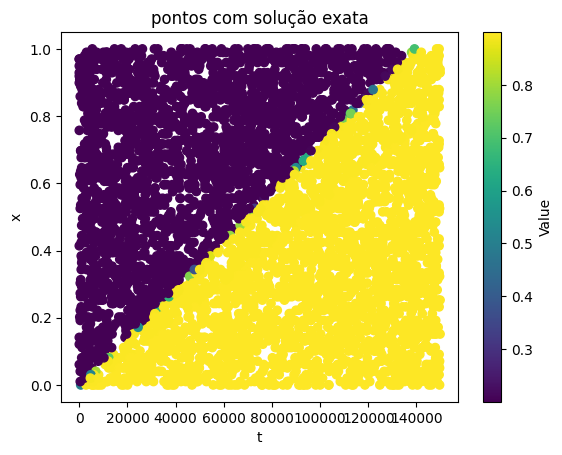

In [7]:
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=u_plot, cmap="viridis", vmin=us.min(), vmax=us.max())
plt.xlabel('t')
plt.ylabel('x')
plt.title('pontos com solução exata')
plt.colorbar(label='Value')
plt.show()

In [8]:
def pinn_loss(X_batch, y_fake, X_contorno, y_contorno, X_inicial, y_inicial, lambda_1 = 0.5, make_reduction=True):
    
    dy_dX = torch.autograd.grad(y_fake, X_batch, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    f_val = f(y_fake)
    df_dy = torch.autograd.grad(f_val, y_fake, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    dy_dt = dy_dX[:, :1]
    dy_dx = dy_dX[:, 1:]
    df_dx = df_dy * dy_dx # regra da cadeia

    if make_reduction:
        L_f = torch.mean((phi * dy_dt + df_dx) ** 2)
        L_b1 = torch.mean((y_inicial - 0.2) ** 2)
        L_b2 = torch.mean((y_contorno - 0.9) ** 2)
    
        return L_f + lambda_1 * (L_b1 + L_b2)
    else:
        L_f = (phi * dy_dt + df_dx) ** 2
        L_b1 = (y_inicial - 0.2) ** 2
        L_b2 = (y_contorno - 0.9) ** 2

        return L_f, L_b1, L_b2

In [9]:
def sample_points(N_colocacao, N_contorno, N_inicial):
    X_colocacao = torch.cat([
        torch.rand(N_colocacao, 1) * T_max,
        torch.rand(N_colocacao, 1)
    ], dim = 1)

    X_contorno = torch.cat([
        torch.rand(N_contorno, 1) * T_max, 
        torch.zeros(N_contorno, 1)
    ], dim = 1)

    X_inicial = torch.cat([
        torch.zeros(N_inicial, 1),
        torch.rand(N_inicial, 1)
    ], dim = 1)

    return X_colocacao, X_contorno, X_inicial

In [10]:
def replace_least_error_points(points, new_points, errors):

    N_todos = points.shape[0]
    N_novos = new_points.shape[0]
    N_resto = N_todos - N_novos
    
    idxs = np.argpartition(-errors.detach().numpy(), N_resto, axis=0).flatten()
    idxs = idxs[:N_resto]

    return torch.cat((points[idxs], new_points), axis=0)    

In [11]:
def resample_ozanski(X_colocacao, X_contorno, X_inicial, model, perc=0.2, perc_boundary=0.1, lambda_1=0.05):

    X_todos = torch.cat((X_contorno, X_inicial, X_colocacao), dim=0).requires_grad_(True)
    
    N_colocacao = X_colocacao.shape[0]
    N_contorno = X_contorno.shape[0]
    N_inicial = X_inicial.shape[0]

    y_fake = model(X_todos)
    y_fake_contorno = y_fake[0:N_contorno, :]
    y_fake_inicial = y_fake[N_contorno:N_contorno + N_inicial, :]

    L_f, L_b1, L_b2 = pinn_loss(X_todos, y_fake, X_contorno, y_fake_contorno, X_inicial, y_fake_inicial, make_reduction=False)

    loss_contorno = L_f[0:N_contorno, :] + lambda_1 * L_b2
    loss_inicial = L_f[N_contorno:N_contorno + N_inicial, :] + lambda_1 * L_b1
    loss_colocacao = L_f[N_contorno + N_inicial:, :]

    X_novos_colocacao, X_novos_contorno, X_novos_inicial = sample_points(int(N_colocacao * perc), int(N_contorno * perc_boundary), int(N_inicial * perc_boundary))

    X_final_colocacao = replace_least_error_points(X_colocacao, X_novos_colocacao, loss_colocacao)
    X_final_contorno = replace_least_error_points(X_contorno, X_novos_contorno, loss_contorno)
    X_final_inicial = replace_least_error_points(X_inicial, X_novos_inicial, loss_inicial)

    return X_final_colocacao, X_final_contorno, X_final_inicial

In [12]:
# _, X_contorno, X_inicial = resample_ozanski(X_colocacao, X_contorno, X_inicial, PINN_model)

In [13]:
class PINN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, z):
        scale = torch.tensor([T_max, 1.0])
        z_normalized = z / scale
        return self.net(z_normalized)

In [14]:
N_colocacao = 5000
N_contorno = 750
N_inicial = 750

X_colocacao, X_contorno, X_inicial = sample_points(N_colocacao, N_contorno, N_inicial)

In [15]:
n_iter = 100000

batch_size = 256
batch_contorno = batch_size // 10
batch_inicial = batch_size // 10
batch_colocacao = batch_size - batch_contorno - batch_inicial

PINN_model = PINN(2, 1, 48)

lr = 1e-3
optimizer = optim.Adam(PINN_model.parameters(), lr=lr)


N_change_points = 100

In [16]:
for it in range(n_iter):

    X_batch_colocacao = X_colocacao[torch.randint(0, N_colocacao, (batch_colocacao,))]
    X_batch_contorno = X_contorno[torch.randint(0, N_contorno, (batch_contorno,))]
    X_batch_inicial = X_inicial[torch.randint(0, N_inicial, (batch_inicial,))]
    # X_batch_colocacao, X_batch_contorno, X_batch_inicial = sample_points(batch_colocacao, batch_contorno, batch_inicial)
    
    X_batch = torch.cat((X_batch_contorno, X_batch_inicial, X_batch_colocacao), dim=0).requires_grad_(True)
    
    y_fake = PINN_model(X_batch)
    y_fake_contorno = y_fake[0:batch_contorno, :]
    y_fake_inicial = y_fake[batch_contorno:batch_contorno + batch_inicial, :]
    
    L_PINN = pinn_loss(X_batch, y_fake, X_batch_contorno, y_fake_contorno, X_batch_inicial, y_fake_inicial)

    optimizer.zero_grad()
    L_PINN.backward()
    optimizer.step()

    if it % N_change_points == 0:
        X_colocacao, X_contorno, X_inicial = resample_ozanski(X_colocacao, X_contorno, X_inicial, PINN_model)
        # N_change_points += 5
    
    if (it + 1) % (n_iter // 10) == 0:
        print(f"Iter {it+1}: L_PINN={L_PINN.item():.10f}")

Iter 10000: L_PINN=0.0003694696
Iter 20000: L_PINN=0.0000038026
Iter 30000: L_PINN=0.0000048654
Iter 40000: L_PINN=0.0000061812
Iter 50000: L_PINN=0.0000000405
Iter 60000: L_PINN=0.0000000094
Iter 70000: L_PINN=0.0071169171
Iter 80000: L_PINN=0.0000448103
Iter 90000: L_PINN=0.0000036605
Iter 100000: L_PINN=0.0000036587


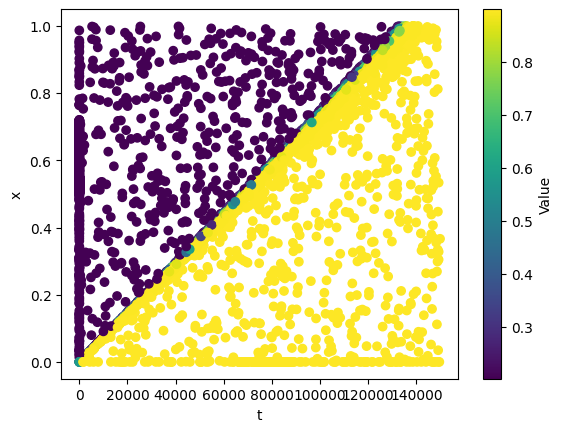

In [17]:
# X_colocacao, X_contorno, X_inicial = sample_points(3400, 300, 300)
x_plot = torch.cat((X_colocacao, X_inicial, X_contorno))
# x_plot = X_colocacao

y_pred = PINN_model(x_plot).detach().numpy()
x_plot = x_plot.detach().numpy()

plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=y_pred, cmap="viridis")
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()

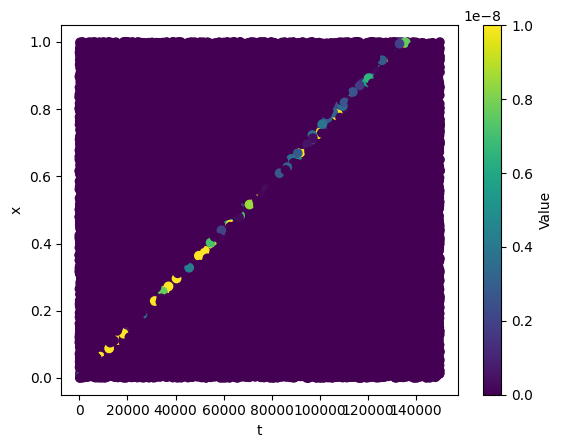

In [21]:
x_plot, *_ = sample_points(50000, 10000, 10000)
x_grad = x_plot.detach().clone().requires_grad_(True)
y_fake = PINN_model(x_grad)
L_f, *_ = pinn_loss(x_grad, y_fake, torch.empty(0, 2), torch.empty(0, 1), torch.empty(0, 2), torch.empty(0, 1), 0.0, False)

x_plot = x_plot.detach().numpy()
L_f = L_f.detach().numpy()

plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=L_f, cmap="viridis", vmax=1e-8)
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()

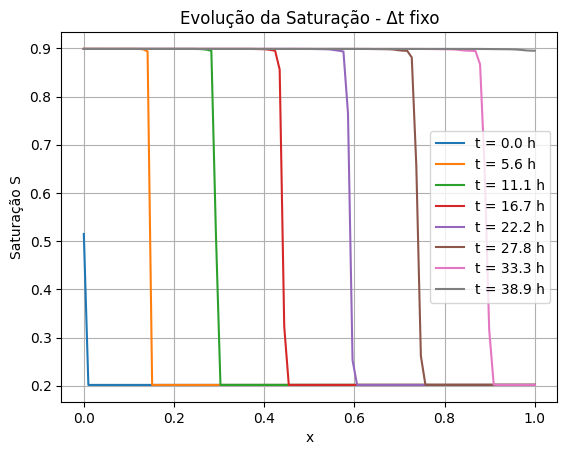

In [19]:
for t in ts[::100]:
    X = torch.tensor(np.stack([np.full(xs.shape, t), xs], axis=1), dtype=torch.float32)
    S = PINN_model(X).detach().cpu().numpy()
    
    plt.plot(xs, S, label=f't = {t/3600:.1f} h')

plt.xlabel('x')
plt.ylabel('Saturação S')
plt.title('Evolução da Saturação - Δt fixo')
plt.legend()
plt.grid(True)
plt.show()